Lucas Galindo - 202222210
Tomas Diaz - 202220658

Primero vamos a cargar los datos y tener una vista inicial de como estan organizados y medidas estadisticas generales para entender y buscar posibless anomalias

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from importlib.metadata import version

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

df = pd.read_csv("Datos Lab 1.csv")
datos = df.copy()
datos.info()
datos.describe()
df = pd.read_csv("Datos Test Lab 1.csv", sep=";")
test_df = df.copy()
test_df.info()
test_df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   object 
 1   Date of Service               1639 non-null   object 
 2   Sex                           1639 non-null   object 
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   object 
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   object 
 13  Dia

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL)
count,183.000000,184.000000,187.000000,186.000000,187.000000,188.00000,186.000000,189.000000,187.000000,188.000000,188.000000,189.000000,189.000000
mean,46.464481,85.583049,1.756995,28.448113,93.666995,196.68617,55.507581,121.249915,175.748813,0.534793,125.618463,83.301741,110.572058
std,12.312220,22.159352,0.118687,7.024220,12.413227,60.02613,15.997907,31.239646,11.399690,0.074244,22.749990,14.753023,62.820276
min,25.000000,19.093000,1.398000,6.698000,70.900000,100.00000,3.410000,16.234000,150.391000,0.377000,90.000000,60.000000,-6.000000
25%,38.000000,65.362250,1.660000,22.908250,82.724000,137.00000,42.250000,98.000000,166.000000,0.484750,107.000000,70.000000,58.000000
50%,44.000000,86.962500,1.760000,28.371500,95.209000,197.00000,55.500000,123.000000,176.000000,0.532000,121.000000,84.000000,106.000000
75%,55.000000,106.525000,1.850000,33.575000,103.050000,251.00000,67.000000,141.000000,185.000000,0.586500,142.000000,93.000000,161.000000
max,77.000000,119.700000,1.989000,49.649000,134.089000,299.00000,89.000000,197.000000,198.949000,0.790000,195.271000,130.029000,289.119000


In [149]:
dict = pd.read_excel('DiccPacientes.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arterial sistólica>/<Presión arterial diastólica>"""
9,Total Cholesterol (mg/dL),Float,Colesterol total


Viendo las estadisticas sabemos que en varias columnas hay valores nulos por lo que tendremos que reemplazar esos datos por la mediana de la respectiva columna que tenga el nulo. Ademas vemos un par de anomalias como mediciones negativas, datos irreales y una edad de 6 lo que no tendria sentido analizar ya que el estudio debe hacerse con adultos. Lo que vamos a solucionar.

In [150]:

datos = datos[datos["Total Cholesterol (mg/dL)"] > 0]
datos = datos[datos["Estimated LDL (mg/dL)"] > 0]
datos = datos[datos["CVD Risk Score"] >= 0]
datos = datos[datos["BMI"] >= 15]
datos = datos[datos["Age"] >= 18]
datos = datos[datos["Systolic BP"] >= 70]
datos = datos[datos["Systolic BP"] <= 200]
datos = datos[datos["Diastolic BP"] >= 40]
datos = datos[datos["Diastolic BP"] <= 130]
datos = datos[datos["HDL (mg/dL)"] >= 20]
datos = datos[datos["Fasting Blood Sugar (mg/dL)"] >= 50]
datos = datos[datos["Fasting Blood Sugar (mg/dL)"] <= 250]
    
print(len(datos))

1095


Al quitar los datos anomalos ahora vamos a revisar si existen duplicados exactos y si hay varios registros de un paciente en diferentes fechas.

In [151]:
print(datos.duplicated().sum())
duplicados = datos.groupby(['Patient ID']).size()
duplicados = duplicados[duplicados > 1]
print(duplicados)

98
Patient ID
BQvQ6431    3
BqZp2317    2
CDsa2651    3
CKKa5109    3
DIVT3121    3
           ..
xbYu9929    3
yAsk5000    2
yvsn3005    2
zcgB3048    2
zxhX5525    2
Length: 114, dtype: int64


Vemos que hay varios duplicados que tenemos que borrar y registros de mismos paciente por lo que vamos a ver si es mejor dejar el ultimo registro o promediarlos o quitarlos.

In [152]:
datos.loc[datos.loc[:,'Patient ID']=="BQvQ6431"]

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
130,BQvQ6431,09/11/2020,M,33.0,118.3,1.69,41.4,72.1,116/93,171.0,...,Moderate,N,210.554,0.427,116.0,93.0,Hypertension Stage 2,97.0,17.500,LOW
1469,BQvQ6431,09/11/2020,M,33.0,118.3,1.69,41.4,72.1,116/93,171.0,...,Moderate,N,210.554,0.427,116.0,93.0,Hypertension Stage 2,97.0,29.833,LOW
1544,BQvQ6431,09/11/2020,M,33.0,118.3,1.69,41.4,72.1,116/93,171.0,...,Moderate,N,210.554,0.427,116.0,93.0,Hypertension Stage 2,97.0,17.500,LOW


Al ver algunos de los registros que tienen mismo ID vemos que son los duplicados y no existen registros en diferentes fechas de un mismo paciente. Sin embargo hay grupos de 3 donde 2 son iguales y otro tiene un CVD Risk Score diferente. Decidimos borrar ambos registros en los casos que tienen diferente score ya que no tenemos la experticia en el tema para saber cual es el score correcto y si promediarlos pueda dar un valor erroneo para el entrenamiento. De igual manera tenemos una gran cantidad de datos y es mejor tener una muestra de buena calidad a una un poco mas grande pero con mayor incertidumebre. 

In [153]:
datos = datos.drop_duplicates()
datos = datos.groupby(['Patient ID', 'Date of Service']).filter(lambda x: x['CVD Risk Score'].nunique() <= 1)
duplicados = datos.groupby(['Patient ID']).size()
duplicados = duplicados[duplicados > 1]
print(duplicados)
print(datos.duplicated().sum())
print(len(datos))

Series([], dtype: int64)
0
853


Ahora que tenemos los datos limpios quitamos las columnas que no sean relevantes o redundantes y que puedan causar multicolinealidad dentro del modelo.

In [154]:

cols_drop = ['Patient ID', 'Date of Service', 'Height (cm)', 
             'Blood Pressure (mmHg)', 'Blood Pressure Category', 
             'Waist-to-Height Ratio', 'CVD Risk Level',
             'Weight (kg)', 'Height (m)', 'Estimated LDL (mg/dL)']

def drop_columns(datos):
    datos = datos.drop(columns=cols_drop, errors='ignore')
    return datos

drop_columns_tr = FunctionTransformer(drop_columns)

Antes de crear el modelo vamos a revisar si existen outliers, si es el caso y representan menos del 5% de la poblacion los vamos a quitar.

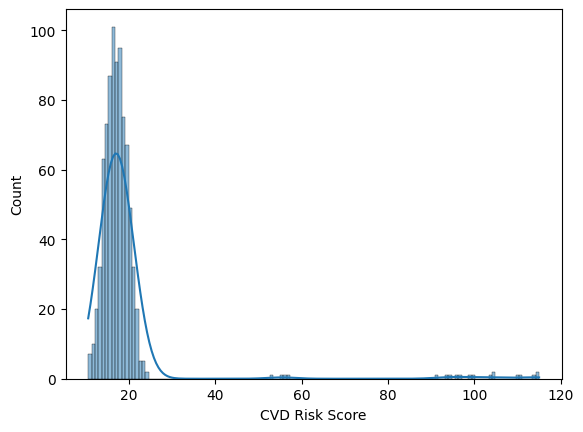

In [155]:
sns.histplot(datos["CVD Risk Score"], kde=True)
plt.show()

Ahora que tenemos los datos limpios, vamos a crear el modelo lineal. Primero comenzaremos con la particion de datos, fijando nuestro objetivo del CVD RISK LEVEL, para poder identificar el riesgo de la poblacion.

In [156]:
datos = datos[datos["CVD Risk Score"] < 30]
target = 'CVD Risk Score'
x = datos.drop(columns=[target])
y = datos[target]


En este caso utilizaremos el 80% de los datos para entrenar el modelo y el 20% de estos para evaluarlo. tomamos esta decision porque nos permite, tener suficiente informacion para el aprendisaje y tener una cantidad optima para evaluarlos

In [157]:
strat = datos['CVD Risk Level']
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=40, stratify=strat)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(667, 23) (167, 23) (667,) (167,)


Ahora se identifican las numericas y categoricas. Para evitar valores nulos, cuando se encuentra un numerico nulo se le coloca la media de esta categoria y si es un categorico, se coloca el mas comun. De igual manera, se estandarizan las variables. Para las categoricas utilizamos el oneHotEncoder, para que se puedan analizar en modo de binarios, usando el ignore para que se puedan manejar categorias no vistas en el entrenamiento y drop if binary para que se elimine las columnas generadas si la variables ya es binaria, para reducir redundancia

In [158]:
numeric_f = ['Age', 
             'Abdominal Circumference (cm)', 
             'Systolic BP', 
             'Diastolic BP', 
             'Total Cholesterol (mg/dL)', 
             'HDL (mg/dL)', 
             'Fasting Blood Sugar (mg/dL)', 
             'BMI']
categorical_f = ['Sex', 
                 'Smoking Status', 
                 'Diabetes Status',
                 'Physical Activity Level', 
                 'Family History of CVD']

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])



Ahora creamos el column transformer para que se apliquen las transformaciones segun el tipo de variable

In [159]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_f),
        ("cat", categorical_transformer, categorical_f),
    ]
)

Ahora creamos el pipeline_regresion, para que todos los datos tengan el mismo procedimiento.

In [160]:


pipeline_regresion = Pipeline(steps=[
    ("dropper", drop_columns_tr),
    ("preprocesamiento", preprocessor)
])
from sklearn import set_config
set_config(display="diagram")
pipeline_regresion

Pipeline(steps=[('dropper',
                 FunctionTransformer(func=<function drop_columns at 0x129f6ba60>)),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Abdominal Circumference '
                                                   '(cm)',
                                                   'Systolic BP',
                                                   'Diastolic BP',
                                                   'Total Cholesterol (mg/dL)',
                                                   'HDL (mg/dL)',
                                                   'Fasting Blood Sugar '
                                                   '(mg/dL)',
                                                   'BMI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Smoking Status',
                                                   'Diabetes Status',
                                                   'Physical Activity Level',
                                                   'Family History of '
                                                   'CVD'])]))])

In [161]:
Xt_train = pipeline_regresion.fit_transform(X_train)
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()


Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names,
    index=X_train.index
)

Se crea el modelo con regression lineal, y se solicita el modelo que genere las predicciones

In [162]:
Modelo = LinearRegression()
Modelo.fit(Xt_train_df, y_train)
y_train_pred = Modelo.predict(Xt_train_df)

Validacion del modelo

In [163]:
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE  train:", mae_train)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
print("RMSE train:", rmse_train)
r2_train = r2_score(y_train, y_train_pred)
print("R²   train:", r2_train)

MAE  train: 0.18806970819932198
RMSE train: 0.5780558039710397
R²   train: 0.9448789556419619


Ahora se hace la estimacion de la capacidad de generalizacion del modelo

In [164]:
Xt_test = pipeline_regresion.transform(X_test)
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
Xt_test_df = pd.DataFrame(
    Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test,
    columns=feature_names,
    index=X_test.index
)

Ahora utilizamos el modelo para predecir en base al conjunto de prueba

In [165]:
y_test_pred = Modelo.predict(Xt_test_df)
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE  test :", mae_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
print("RMSE test :", rmse_test)
r2_test = r2_score(y_test, y_test_pred)
print("R²   test :", r2_test)

MAE  test : 0.19507573753299415
RMSE test : 0.5176147028152724
R²   test : 0.9603681600094305


Ahora vamos a hacer un segundo modelo, normalizando los valores con logaritmo para ver si logramos tener una mejor representacion de los datos.

In [166]:
target = 'CVD Risk Score'
x = datos.drop(columns=[target])
y = np.log1p(datos[target])

X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

numeric_f = ['Age', 
             'Abdominal Circumference (cm)', 
             'Systolic BP', 
             'Diastolic BP',
             'Total Cholesterol (mg/dL)', 
             'HDL (mg/dL)',
             'Fasting Blood Sugar (mg/dL)', 
             'BMI']

categorical_f = ['Sex', 
                 'Smoking Status', 
                 'Diabetes Status',
                 'Physical Activity Level', 
                 'Family History of CVD']

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_f),
        ("cat", categorical_transformer, categorical_f),
    ]
)

pipeline_regresion = Pipeline(steps=[
    ("dropper", drop_columns_tr),
    ("preprocesamiento", preprocessor),
])
from sklearn import set_config
set_config(display="diagram")
pipeline_regresion

Xt_train = pipeline_regresion.fit_transform(X_train)
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names,
    index=X_train.index
)

Modelo2 = LinearRegression()
Modelo2.fit(Xt_train_df, y_train)
y_train_pred = Modelo2.predict(Xt_train_df)

mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE  train:", mae_train)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
print("RMSE train:", rmse_train)
r2_train = r2_score(y_train, y_train_pred)
print("R²   train:", r2_train)

Xt_test = pipeline_regresion.transform(X_test)
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
Xt_test_df = pd.DataFrame(
    Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test,
    columns=feature_names,
    index=X_test.index
)

y_test_pred = Modelo2.predict(Xt_test_df)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

print("MAE test  :", mean_absolute_error(y_test_real, y_test_pred_real))
print("RMSE test :", np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))
print("R² test   :", r2_score(y_test_real, y_test_pred_real))

(667, 23) (167, 23) (667,) (167,)
MAE  train: 0.01388829391536145
RMSE train: 0.033059712141024385
R²   train: 0.9442106803422622
MAE test  : 0.2755373937062731
RMSE test : 0.7634943021849039
R² test   : 0.9097671547349557
